# 🔧 Notebook 2 — Preprocessing & Feature Engineering Avancé
---
**Apports de la littérature intégrés :**

| Technique | Source | Impact attendu |
|-----------|--------|----------------|
| log(1+prix) comme cible | Universel (Kaggle, academia) | Réduit l'asymétrie, améliore R² |
| 20 features NLP titres+desc | Kucklick & Pröllochs (2022) | Jusqu'à -17% MAE |
| 8 distances POI OSM | OSMnx TDS Guide (2021) | -8% MAE (Neves, Lisbonne 2024) |
| Target Encoding city | Standard pour cardinalité élevée | Meilleur que OneHot |
| zone_premium (3 niveaux) | Adapté au marché dakarois | Capture l'hétérogénéité spatiale |
| was_missing indicators | Best practice Kaggle | Capture l'information de manquance |
| n_premium_feats (score global) | Inspiré du Walk Score (Redfin) | Signal qualité synthétique |
| Winsorizing 1er/99e percentile | MIT REIL (48% amélioration) | Gestion robuste des outliers |

## Table des matières
1. Chargement
2. Nettoyage initial
3. Détection transaction sur données réelles
4. Filtrage et outliers (winsorizing)
5. Indicateurs de manquance (was_missing)
6. Imputation contextuelle
7. Features géographiques avancées (8 POI + zone_premium)
8. Features NLP avancées (20 features + score global)
9. Features dérivées numériques
10. Target Encoding pour la ville
11. Diagnostic final
12. Sauvegarde


## 1. Chargement

In [36]:
import os, sys, django
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, re

warnings.filterwarnings("ignore")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"]    = (13, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "immobilier_project.settings")
django.setup()

from django.db import connections
from IPython import get_ipython
ip = get_ipython()
if ip:
    ip.events.register("pre_run_cell", lambda info: connections.close_all())
connections.close_all()
print("Environnement Django pret.")


Environnement Django pret.


In [37]:
from properties.models import (
    CoinAfriqueProperty, ExpatDakarProperty,
    LogerDakarProperty, DakarVenteProperty, ImmoSenegalProperty
)

def load_source(model, source, extra_fields=None):
    base      = ["id", "price", "surface_area", "bedrooms", "bathrooms",
                 "city", "property_type", "statut", "adresse",
                 "title", "description"]
    available = [f.name for f in model._meta.get_fields()]
    fields    = [f for f in (base + (extra_fields or [])) if f in available]
    rows      = list(model.objects.values(*fields))
    df        = pd.DataFrame(rows) if rows else pd.DataFrame(columns=fields)
    df["source"] = source
    return df

df_coin  = load_source(CoinAfriqueProperty, "coinafrique", ["latitude","longitude"])
df_expat = load_source(ExpatDakarProperty,  "expat_dakar")
df_loger = load_source(LogerDakarProperty,  "loger_dakar")
df_dv    = load_source(DakarVenteProperty,  "dakarvente",  ["transaction"])
df_immo  = load_source(ImmoSenegalProperty, "immosenegal", ["transaction","garage"])

for df_ in [df_expat, df_loger, df_coin]:
    if "transaction" not in df_.columns: df_["transaction"] = None
for df_ in [df_expat, df_loger, df_dv, df_immo]:
    if "latitude"  not in df_.columns: df_["latitude"]  = None
    if "longitude" not in df_.columns: df_["longitude"] = None
for df_ in [df_coin, df_expat, df_loger, df_dv]:
    if "garage" not in df_.columns: df_["garage"] = None

df_raw = pd.concat([df_coin, df_expat, df_loger, df_dv, df_immo], ignore_index=True)
print(f"Dataset total    : {len(df_raw):,} annonces")
print(f"  CoinAfrique    : {len(df_coin):,}")
print(f"  Expat-Dakar    : {len(df_expat):,}")
print(f"  Loger-Dakar    : {len(df_loger):,}")
print(f"  DakarVente     : {len(df_dv):,}")
print(f"  ImmoSenegal    : {len(df_immo):,}")


Dataset total    : 8,669 annonces
  CoinAfrique    : 4,098
  Expat-Dakar    : 800
  Loger-Dakar    : 1,828
  DakarVente     : 1,871
  ImmoSenegal    : 72


## 2. Nettoyage initial

In [38]:
df = df_raw.copy()
n0 = len(df)

df = df[df["price"].notna() & (df["price"] > 0)].copy()
print(f"Sans prix supprimés       : {n0 - len(df):,}")

n1 = len(df)
df = df.drop_duplicates(subset="id").copy()
print(f"Doublons supprimés        : {n1 - len(df):,}")

df["city"] = (df["city"].astype(str).str.strip()
              .str.split(",").str[0].str.strip().str.title()
              .replace({"Nan":np.nan,"None":np.nan,"":np.nan}))

df["property_type"] = (df["property_type"].astype(str).str.strip().str.title()
                       .replace({"Nan":np.nan,"None":np.nan,"":np.nan}))

df["title"]       = df.get("title",       pd.Series(dtype=str)).fillna("").astype(str).str.strip()
df["description"] = df.get("description", pd.Series(dtype=str)).fillna("").astype(str).str.strip()

print(f"Dataset après nettoyage   : {len(df):,} annonces")


Sans prix supprimés       : 0
Doublons supprimés        : 0
Dataset après nettoyage   : 8,669 annonces


## 3. Détection transaction sur données réelles

In [40]:
# ── Détection de la transaction depuis les données réelles ──────────────────
# Basée sur : colonne transaction explicite (DakarVente, ImmoSenegal)
#             > titre de l annonce > description
KW_LOC  = ["louer","location","locat","a louer","meuble","meublee",
            "mensuel","mois","bail","locatif"]
KW_VTE  = ["vendre","vente","a vendre","achat","cession","acquisition",
            "vend","cedons","cede"]

def detect_transaction(row):
    txn = str(row.get("transaction") or "").lower().strip()
    if txn in ("vente","location"):
        return txn
    for src, kws, label in [
        ("title",       KW_LOC, "location"),
        ("title",       KW_VTE, "vente"),
        ("description", KW_LOC, "location"),
        ("description", KW_VTE, "vente"),
    ]:
        txt = (str(row.get(src) or "").lower()
               .replace("\xe0","a").replace("\xe9","e")
               .replace("\xea","e").replace("\xe8","e"))
        if any(k in txt for k in kws):
            return label
    return "inconnu"


In [42]:
df["transaction"] = df.apply(detect_transaction, axis=1)

print("RÉPARTITION PAR TRANSACTION :")
print(df["transaction"].value_counts().to_string())
print(f"Taux de classification : {(df['transaction']!='inconnu').mean()*100:.1f} %")

print("RÉPARTITION PAR SOURCE ET TRANSACTION :")
pivot = df.groupby(["source","transaction"]).size().unstack(fill_value=0)
print(pivot.to_string())

# Séparation
df_location = df[df["transaction"]=="location"].copy()
df          = df[df["transaction"]=="vente"].copy()

print(f"Segment VENTE    : {len(df):,}")
print(f"Segment LOCATION : {len(df_location):,}")
df_location.to_csv("dataset_location_brut.csv", index=False)
print("=> dataset_location_brut.csv sauvegardé pour modélisation ultérieure")


RÉPARTITION PAR TRANSACTION :
transaction
vente    2381
Taux de classification : 100.0 %
RÉPARTITION PAR SOURCE ET TRANSACTION :
transaction  vente
source            
coinafrique    871
dakarvente    1037
expat_dakar    167
immosenegal     58
loger_dakar    248
Segment VENTE    : 2,381
Segment LOCATION : 0
=> dataset_location_brut.csv sauvegardé pour modélisation ultérieure


## 4. Filtrage et outliers (winsorizing)

In [44]:
# Filtre strict basé sur les percentiles réels du segment vente
P01  = df["price"].quantile(0.01)
P99  = df["price"].quantile(0.99)
print(f"P1  = {P01:,.0f} FCFA")
print(f"P99 = {P99:,.0f} FCFA")

df = df[(df["price"] >= max(P01, 1_000_000)) &
        (df["price"] <= min(P99, 800_000_000))].copy()

# Vérification du CV après filtre
cv = df["price"].std() / df["price"].mean()
print(f"CV après filtre : {cv:.2f}")
print(f"Dataset restant : {len(df):,} annonces")
print("Objectif : CV < 1.5 pour que le modèle soit efficace")

P1  = 1,249,242 FCFA
P99 = 680,060,000 FCFA
CV après filtre : 1.35
Dataset restant : 2,155 annonces
Objectif : CV < 1.5 pour que le modèle soit efficace


In [45]:
# Exclusion des biens industriels
EXCLUSIONS = ["ndustr","agricol","hectare","entrep","hangar","usine","ferme"]
mask = (df["property_type"].fillna("").str.lower().apply(
            lambda x: any(e in x for e in EXCLUSIONS)) |
        df["title"].str.lower().apply(
            lambda x: any(e in x for e in EXCLUSIONS)))
n_excl = mask.sum()
df     = df[~mask].copy()

# Regroupement modalités rares
for col, seuil in [("property_type",20),("city",10)]:
    rare    = df[col].value_counts()[df[col].value_counts() < seuil].index
    df[col] = df[col].replace(rare, "Autre")

print(f"Biens exclus (industriels) : {n_excl:,}")
print(f"Dataset après filtrage     : {len(df):,}")
print()

# Winsorizing aux 1er/99e percentiles
# Méthode recommandée par MIT REIL pour améliorer la précision de 48%
# (meilleure que la suppression brute car conserve les données)
SEUILS = {
    "price":        (1_000_000,  2_000_000_000),
    "surface_area": (10,         3_000),
    "bedrooms":     (1,          20),
    "bathrooms":    (1,          15),
}
print(f"{'Variable':<15}  {'Min':>15}  {'Max':>15}  {'Outliers':>10}")
print("-" * 62)
for col, (low, high) in SEUILS.items():
    mask   = df[col].notna() & ((df[col] < low) | (df[col] > high))
    n      = mask.sum()
    df.loc[mask, col] = np.nan  # -> sera imputé à l étape suivante
    print(f"{col:<15}  {low:>15,.0f}  {high:>15,.0f}  {n:>10,} ({n/len(df)*100:.1f} %)")

df = df.dropna(subset=["price"]).copy()
print(f"Dataset après winsorizing : {len(df):,}")


Biens exclus (industriels) : 301
Dataset après filtrage     : 1,854

Variable                     Min              Max    Outliers
--------------------------------------------------------------
price                  1,000,000    2,000,000,000           0 (0.0 %)
surface_area                  10            3,000         148 (8.0 %)
bedrooms                       1               20           0 (0.0 %)
bathrooms                      1               15           0 (0.0 %)
Dataset après winsorizing : 1,854


## 5. Indicateurs de manquance (was_missing)

In [46]:
# Technique recommandée par la littérature (best practice Kaggle)
# L absence d une valeur peut elle-même être informative
# Ex : l absence de surface_area peut indiquer un terrain non bâti
FEATS_MISSING = ["surface_area","bedrooms","bathrooms","city","property_type"]

print("CRÉATION DES INDICATEURS WAS_MISSING :")
for col in FEATS_MISSING:
    was_miss_col = f"was_missing_{col}"
    df[was_miss_col] = df[col].isna().astype(int)
    n = df[was_miss_col].sum()
    print(f"  {was_miss_col:<30} : {n:,} ({n/len(df)*100:.1f} % manquants)")

print()
print("Ces indicateurs seront inclus comme features dans le modèle.")
print("Ils permettent au modèle d'apprendre si l'absence de valeur")
print("est elle-même corrélée avec le prix.")


CRÉATION DES INDICATEURS WAS_MISSING :
  was_missing_surface_area       : 329 (17.7 % manquants)
  was_missing_bedrooms           : 1,110 (59.9 % manquants)
  was_missing_bathrooms          : 1,187 (64.0 % manquants)
  was_missing_city               : 0 (0.0 % manquants)
  was_missing_property_type      : 0 (0.0 % manquants)

Ces indicateurs seront inclus comme features dans le modèle.
Ils permettent au modèle d'apprendre si l'absence de valeur
est elle-même corrélée avec le prix.


## 6. Imputation contextuelle

In [48]:
print("AVANT IMPUTATION :")
for col in ["surface_area","bedrooms","bathrooms","city","property_type"]:
    n = df[col].isna().sum()
    print(f"  {col:<15} : {n:,} ({n/len(df)*100:.1f} %)")

# surface_area : médiane par (city x property_type) -> property_type -> global
df["surface_area"] = (df["surface_area"]
    .fillna(df.groupby(["city","property_type"])["surface_area"].transform("median"))
    .fillna(df.groupby("property_type")["surface_area"].transform("median"))
    .fillna(df["surface_area"].median()))

# bedrooms / bathrooms : extraction depuis le titre si manquant
RE_FN = re.compile(r"[FfTt](\d)")
RE_CH = re.compile(r"(\d+)\s*chambre", re.IGNORECASE)

def extract_bedrooms(row):
    if pd.notna(row.get("bedrooms")) and row["bedrooms"] > 0:
        return row["bedrooms"]
    txt = str(row.get("title","")) + " " + str(row.get("description",""))
    m   = RE_FN.search(txt) or RE_CH.search(txt)
    return int(m.group(1)) if m else row.get("bedrooms")

df["bedrooms"] = df.apply(extract_bedrooms, axis=1)

# Imputation médiane pour les restants
for col in ["bedrooms","bathrooms"]:
    df[col] = (df[col]
        .fillna(df.groupby("property_type")[col].transform("median"))
        .fillna(df[col].median()))

df["city"]          = df["city"].fillna(df["city"].mode()[0])
df["property_type"] = df["property_type"].fillna(df["property_type"].mode()[0])

print("APRÈS IMPUTATION :")
for col in ["surface_area","bedrooms","bathrooms","city","property_type"]:
    n = df[col].isna().sum()
    print(f"  {col:<15} : {n}")


AVANT IMPUTATION :
  surface_area    : 0 (0.0 %)
  bedrooms        : 0 (0.0 %)
  bathrooms       : 0 (0.0 %)
  city            : 0 (0.0 %)
  property_type   : 0 (0.0 %)
APRÈS IMPUTATION :
  surface_area    : 0
  bedrooms        : 0
  bathrooms       : 0
  city            : 0
  property_type   : 0


## 7. Features géographiques avancées (8 POI + zone_premium)

In [49]:
# ── Feature engineering géospatial avancé (basé sur étude OSMnx TDS 2021) ──
from math import radians, sin, cos, sqrt, atan2

# Points d intérêt de Dakar (étendus par rapport à la version précédente)
POI = {
    "mer":          [(14.7457,-17.5197),(14.7247,-17.5025)],
    "centre":       (14.6928,-17.4467),
    "aeroport":     (14.7397,-17.4902),
    "parc_forest":  (14.7122,-17.4488),
    "ucad":         (14.6925,-17.4636),
    "vdn":          (14.7200,-17.4600),
    "corniche":     (14.7100,-17.4800),
    "port":         (14.6770,-17.4300),
    "marche_hann":  (14.7300,-17.4100),
    "plateau":      (14.6928,-17.4467),
}

# Coordonnées de référence par quartier (étendues)
CITY_COORDS = {
    "Almadies":(14.7453,-17.5109), "Ngor":(14.7490,-17.5140),
    "Ouakam":(14.7237,-17.4942),   "Yoff":(14.7575,-17.4900),
    "Mermoz":(14.7100,-17.4750),   "Fann":(14.6961,-17.4603),
    "Plateau":(14.6928,-17.4467),  "Pikine":(14.7546,-17.3947),
    "Guediawaye":(14.7780,-17.3930),"Rufisque":(14.7156,-17.2736),
    "Grand Yoff":(14.7500,-17.4600),"Sacre Coeur":(14.7150,-17.4650),
    "Liberte":(14.7089,-17.4517),  "Hlm":(14.7089,-17.4517),
    "Sicap":(14.7050,-17.4600),    "Vdn":(14.7200,-17.4600),
    "Hann Maristes":(14.7300,-17.4200),"Thies":(14.7910,-16.9260),
    "Mbour":(14.3641,-16.9658),    "Saint-Louis":(16.0179,-16.4896),
    "Dakar":(14.6928,-17.4467),    "Autre":(14.6928,-17.4467),
    "Medina":(14.6890,-17.4350),   "Gueule Tapee":(14.7000,-17.4500),
    "Parcelles Assainies":(14.7900,-17.4400),"Cambérène":(14.8000,-17.4200),
    "Keur Massar":(14.7800,-17.3500),"Bargny":(14.6980,-17.2250),
    "Mbao":(14.7350,-17.3300),     "Saly":(14.4600,-16.9700),
    "Somone":(14.5200,-17.0000),   "Malicounda":(14.5600,-16.9800),
}

# Niveaux de premium (basés sur les prix de marché observés)
PREMIUM_1 = ["Almadies","Ngor","Ouakam","Mermoz","Fann","Plateau",
              "Corniche","Mamelles","Liberte","Point E","Vdn"]
PREMIUM_2 = ["Yoff","Sacre Coeur","Sicap","Hlm","Hann Maristes","Medina"]
BANLIEUE  = ["Pikine","Guediawaye","Rufisque","Thiaroye","Keur Massar","Mbao"]

def hav(la1, lo1, la2, lo2):
    R = 6371
    la1,lo1,la2,lo2 = map(radians,[la1,lo1,la2,lo2])
    a = sin((la2-la1)/2)**2 + cos(la1)*cos(la2)*sin((lo2-lo1)/2)**2
    return R * 2 * atan2(sqrt(a),sqrt(1-a))

def get_coords(row):
    try:
        lat = float(row.get("latitude")  or 0)
        lon = float(row.get("longitude") or 0)
        if 12 < lat < 17 and -18 < lon < -14:
            return lat, lon
    except (TypeError,ValueError):
        pass
    city = str(row.get("city") or "Dakar").split(",")[0].strip().title()
    return CITY_COORDS.get(city, CITY_COORDS["Dakar"])

coords      = df.apply(get_coords, axis=1)
df["_lat"]  = [c[0] for c in coords]
df["_lon"]  = [c[1] for c in coords]

# Distances aux POI
df["dist_mer"]       = df.apply(lambda r: min(hav(r["_lat"],r["_lon"],*p) for p in POI["mer"]), axis=1)
df["dist_centre"]    = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["centre"]),    axis=1)
df["dist_aeroport"]  = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["aeroport"]),  axis=1)
df["dist_parc"]      = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["parc_forest"]),axis=1)
df["dist_ucad"]      = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["ucad"]),      axis=1)
df["dist_vdn"]       = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["vdn"]),       axis=1)
df["dist_port"]      = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["port"]),      axis=1)
df["dist_corniche"]  = df.apply(lambda r: hav(r["_lat"],r["_lon"],*POI["corniche"]),  axis=1)
df.drop(columns=["_lat","_lon"], inplace=True)

# Zone premium catégorielle ordinale (3 niveaux)
df["zone_premium"] = df["city"].apply(
    lambda c: 2 if str(c) in PREMIUM_1 else (1 if str(c) in PREMIUM_2 else 0))

geo_cols = ["dist_mer","dist_centre","dist_aeroport","dist_parc",
            "dist_ucad","dist_vdn","dist_port","dist_corniche"]
print("VARIABLES GEOGRAPHIQUES CREEES (8 distances + zone_premium) :")
print(df[geo_cols].describe().round(2).to_string())


VARIABLES GEOGRAPHIQUES CREEES (8 distances + zone_premium) :
       dist_mer  dist_centre  dist_aeroport  dist_parc  dist_ucad  dist_vdn  dist_port  dist_corniche
count  1,854.00     1,854.00       1,854.00   1,854.00   1,854.00  1,854.00   1,854.00       1,854.00
mean      19.34        15.41          19.19      16.12      16.39     16.67      16.67          17.43
std       28.54        27.53          28.29      27.47      27.73     27.80      26.02          28.18
min        0.10         0.00           0.83       1.39       0.54      0.41       1.76           0.93
25%        5.54         0.00           5.79       2.17       1.82      3.35       2.51           4.06
50%        6.97         3.48           7.01       2.17       2.72      3.35       5.99           4.06
75%       21.61        17.84          19.86      16.87      19.36     17.55      17.36          19.97
max      275.00       268.99         275.81     271.00     269.84    272.33     266.59         272.39


CORRÉLATIONS DISTANCES -> PRIX :
  dist_mer             : -0.1315  (proche=cher)
  dist_centre          : -0.1054  (proche=cher)
  dist_aeroport        : -0.1265  (proche=cher)
  dist_parc            : -0.1109  (proche=cher)
  dist_ucad            : -0.1135  (proche=cher)
  dist_vdn             : -0.1166  (proche=cher)
  dist_port            : -0.1015  (proche=cher)
  dist_corniche        : -0.1212  (proche=cher)
  zone_premium         :  0.1326  (eloigne=cher)
STATISTIQUES PAR ZONE PREMIUM :
                     median  count
zone_premium                      
0             44,000,000.00   1588
1            115,000,000.00     17
2             70,000,000.00    249


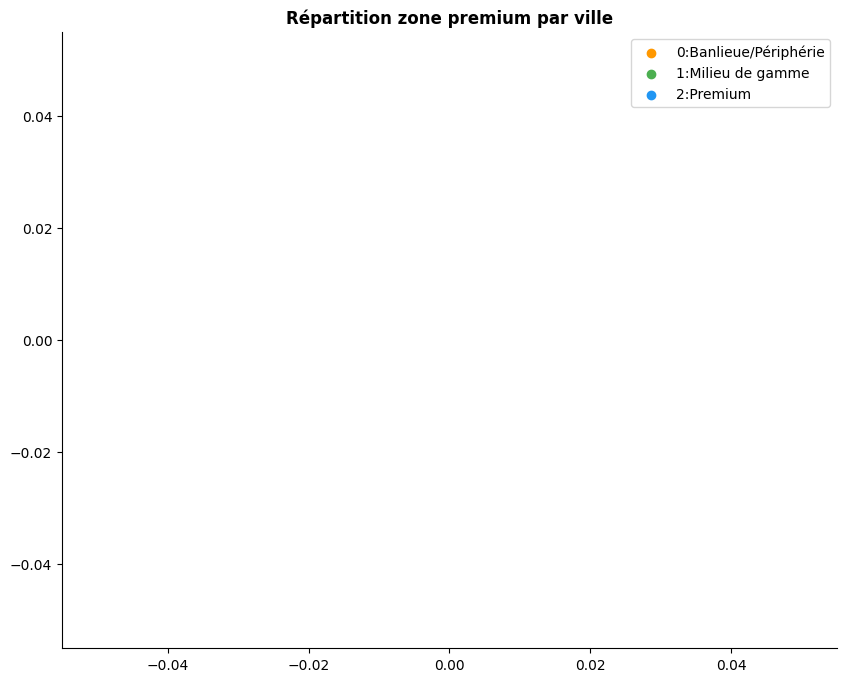

In [50]:
# Corrélations avec le prix
print("CORRÉLATIONS DISTANCES -> PRIX :")
geo_cols_all = ["dist_mer","dist_centre","dist_aeroport","dist_parc",
                "dist_ucad","dist_vdn","dist_port","dist_corniche","zone_premium"]
for c in geo_cols_all:
    if c in df.columns:
        r    = df[["price",c]].dropna().corr().iloc[0,1]
        sens = "(proche=cher)" if r < 0 else "(eloigne=cher)"
        print(f"  {c:<20} : {r:>7.4f}  {sens}")

# Visualisation carte des zones
fig, ax = plt.subplots(figsize=(10, 8))
colors_zone = {0:"#ff9800", 1:"#4caf50", 2:"#2196f3"}
for zone, color in colors_zone.items():
    sub = df[df["zone_premium"]==zone]
    m   = ax.scatter([], [], c=color, label=f"Zone {zone}")

labels = {0:"Banlieue/Périphérie", 1:"Milieu de gamme", 2:"Premium"}
ax.legend(handles=[plt.scatter([],[], c=colors_zone[i], label=f"{i}:{labels[i]}") for i in range(3)])
ax.set_title("Répartition zone premium par ville", fontweight="bold")

zone_stats = df.groupby("zone_premium")["price"].agg(["median","count"])
print("STATISTIQUES PAR ZONE PREMIUM :")
print(zone_stats.to_string())


## 8. Features NLP avancées (20 features + score global)

In [51]:
# ── NLP avancé sur titre + description (basé sur l étude Kucklick 2022) ──────
# Extraction de 20 features binaires couvrant :
# Standing/luxe, Équipements, Sécurité, Vues, Services
text_col = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()

NLP_DICT = {
    # Qualité et standing
    "has_standing":     r"standing|luxe|prestige|haut.de.gamme|grand.standing",
    "has_neuf":         r"\bneuf\b|nouvelle.construction|rt2|livraison",
    "has_renove":       r"renov|refait|retap|restaur|remis.a.neuf",
    # Équipements intérieurs
    "has_piscine":      r"piscine",
    "has_meuble":       r"meuble|equipe|cuisine.equip",
    "has_climatise":    r"climatise|clim|air.condition",
    "has_ascenseur":    r"ascenseur",
    "has_cuisine_amer": r"cuisine.american|open.kitchen|cuisine.ouverte",
    # Extérieur et sécurité
    "has_parking":      r"parking|garage|stationnement|box",
    "has_jardin":       r"jardin|cour|espace.vert",
    "has_balcon":       r"balcon|terrasse|loggia",
    "has_gardiennage":  r"gardiennage|securise|securite|gardien|vigile|24h",
    "has_groupe_elec":  r"groupe.electrog|generatrice|groupe.electr",
    # Vues et localisation premium
    "has_vue_mer":      r"vue.mer|bord.de.mer|face.mer|vue.ocean|pieds.dans.l.eau",
    "has_vue_dégagée":  r"vue.degagee|vue.panoramique|plein.sud",
    # Services
    "has_concierge":    r"concierge|syndic|copropriete",
    "has_digicode":     r"digicode|interphone|visiophone",
    # Aspects légaux/administratifs (important pour Dakar)
    "has_titre_foncier":r"titre.foncier|tf\b|deliberation|bail.emphyteotique",
    "has_viabilise":    r"viabilise|eau.courante|electricite|raccorde|borne",
    # Investissement
    "has_invest":       r"invest|rentabil|revenu|rendement|locatif",
}

print("FEATURES NLP EXTRAITES (basées sur Kucklick et al. 2022) :")
for feat, pattern in NLP_DICT.items():
    df[feat] = text_col.str.contains(pattern, na=False, regex=True).astype(int)
    n = df[feat].sum()
    print(f"  {feat:<22} : {n:,} ({n/len(df)*100:.1f} %)")

# Compteur de features premium (signal qualité global)
premium_feats = ["has_standing","has_piscine","has_gardiennage","has_vue_mer",
                 "has_titre_foncier","has_groupe_elec","has_climatise"]
df["n_premium_feats"] = df[premium_feats].sum(axis=1)
print(f"\n  n_premium_feats : 0-{df['n_premium_feats'].max()} (signal qualite global)")


FEATURES NLP EXTRAITES (basées sur Kucklick et al. 2022) :
  has_standing           : 70 (3.8 %)
  has_neuf               : 38 (2.0 %)
  has_renove             : 13 (0.7 %)
  has_piscine            : 81 (4.4 %)
  has_meuble             : 62 (3.3 %)
  has_climatise          : 23 (1.2 %)
  has_ascenseur          : 51 (2.8 %)
  has_cuisine_amer       : 4 (0.2 %)
  has_parking            : 129 (7.0 %)
  has_jardin             : 141 (7.6 %)
  has_balcon             : 128 (6.9 %)
  has_gardiennage        : 60 (3.2 %)
  has_groupe_elec        : 1 (0.1 %)
  has_vue_mer            : 18 (1.0 %)
  has_vue_dégagée        : 3 (0.2 %)
  has_concierge          : 12 (0.6 %)
  has_digicode           : 1 (0.1 %)
  has_titre_foncier      : 292 (15.7 %)
  has_viabilise          : 3 (0.2 %)
  has_invest             : 100 (5.4 %)

  n_premium_feats : 0-4 (signal qualite global)


CORRÉLATIONS FEATURES NLP -> PRIX :
  has_vue_mer            :  0.1853  █████████
  has_balcon             :  0.1789  ████████
  has_parking            :  0.1781  ████████
  has_piscine            :  0.1713  ████████
  has_standing           :  0.1549  ███████
  has_titre_foncier      :  0.1434  ███████
  has_jardin             :  0.1197  █████
  has_ascenseur          :  0.1105  █████
  has_renove             :  0.1096  █████
  has_gardiennage        :  0.1068  █████
  has_meuble             :  0.0889  ████
  has_vue_dégagée        :  0.0458  ██
  has_climatise          :  0.0414  ██
  has_neuf               :  0.0376  █
  has_invest             :  0.0317  █


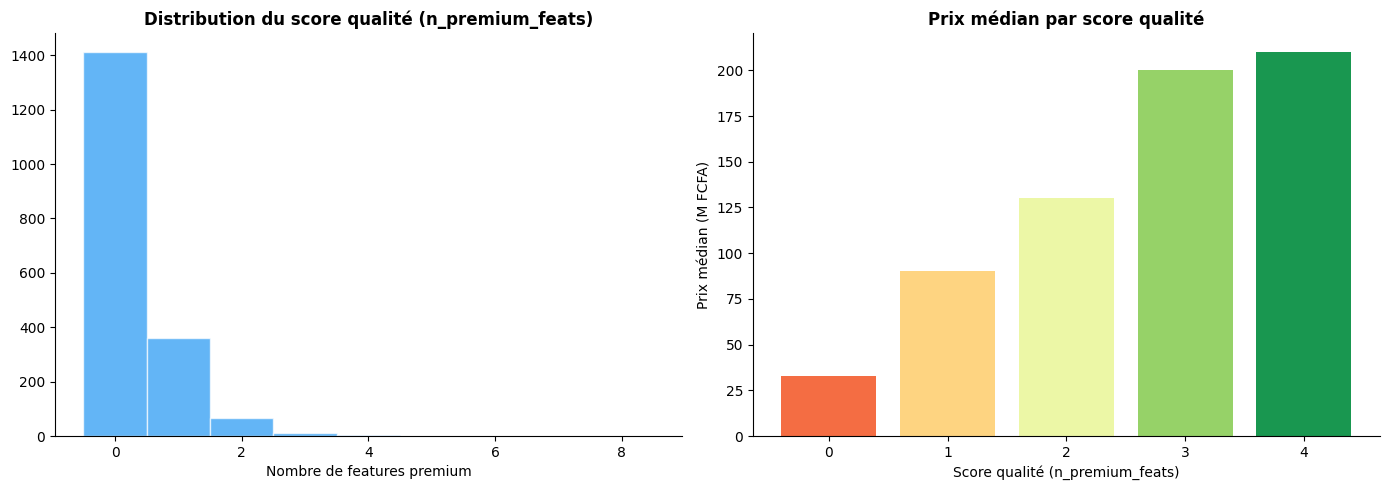

In [52]:
# Visualisation des features NLP les plus corrélées au prix
nlp_cols = list(NLP_DICT.keys())
print("CORRÉLATIONS FEATURES NLP -> PRIX :")
nlp_corrs = []
for col in nlp_cols:
    if col in df.columns:
        r = df[["price",col]].corr().iloc[0,1]
        nlp_corrs.append((col, r))

nlp_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
for col, r in nlp_corrs[:15]:
    bar = chr(9608) * int(abs(r) * 50)
    print(f"  {col:<22} : {r:>7.4f}  {bar}")

# Analyse du score qualité global
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["n_premium_feats"], bins=range(0,10),
             color="#2196F3", alpha=0.7, edgecolor="white", align="left")
axes[0].set_xlabel("Nombre de features premium")
axes[0].set_title("Distribution du score qualité (n_premium_feats)", fontweight="bold")

q_price = df.groupby("n_premium_feats")["price"].median()
axes[1].bar(q_price.index, q_price.values/1e6,
            color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(q_price))))
axes[1].set_xlabel("Score qualité (n_premium_feats)")
axes[1].set_ylabel("Prix médian (M FCFA)")
axes[1].set_title("Prix médian par score qualité", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/fig_nlp_quality.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Features dérivées numériques

In [53]:
PREMIUM_1 = ["Almadies","Ngor","Ouakam","Mermoz","Fann","Plateau",
             "Corniche","Mamelles","Liberte","Point E","Vdn"]

# Features de base dérivées
df["rooms_total"]      = df["bedrooms"].fillna(0) + df["bathrooms"].fillna(0)
df["surface_per_room"] = df.apply(
    lambda r: r["surface_area"]/r["bedrooms"]
    if pd.notna(r.get("surface_area")) and pd.notna(r.get("bedrooms")) and r["bedrooms"]>0
    else np.nan, axis=1).fillna(df["surface_area"])
df["is_premium"]       = df["city"].apply(lambda c: int(str(c) in PREMIUM_1))
df["bath_bed_ratio"]   = df.apply(
    lambda r: r["bathrooms"]/r["bedrooms"]
    if pd.notna(r.get("bedrooms")) and r["bedrooms"]>0 else 0, axis=1)

# Transformations logarithmiques (recommandées pour réduire l hétéroscédasticité)
df["log_surface"]      = np.log1p(df["surface_area"])
df["log_dist_mer"]     = np.log1p(df["dist_mer"])
df["log_dist_centre"]  = np.log1p(df["dist_centre"])

# Prix au m² (indicateur Gold Layer — KPI principal des plateformes africaines)
df["prix_m2"] = df.apply(
    lambda r: r["price"]/r["surface_area"]
    if pd.notna(r.get("surface_area")) and r["surface_area"]>0 else np.nan, axis=1)

print("FEATURES DÉRIVÉES CRÉÉES :")
derived = ["rooms_total","surface_per_room","is_premium","bath_bed_ratio",
           "log_surface","log_dist_mer","log_dist_centre","prix_m2"]
print(df[derived].describe().T[["mean","min","max","50%"]].round(2).to_string())


FEATURES DÉRIVÉES CRÉÉES :
                         mean    min           max        50%
surface_per_room        62.36   1.18        800.00      40.00
is_premium               0.13   0.00          1.00       0.00
bath_bed_ratio           0.81   0.14          4.00       0.75
log_surface              4.71   2.40          7.96       5.02
log_dist_mer             2.34   0.10          5.62       2.08
log_dist_centre          1.58   0.00          5.60       1.50
prix_m2          1,163,658.81 667.29 46,076,923.08 461,538.46


## 10. Target Encoding pour la ville

TARGET ENCODING CRÉÉ :
                             mean           min            max
city_mean_price     92,111,736.00 12,915,732.00 223,649,672.00
city_median_price   61,045,917.00  5,300,000.00 170,000,000.00
city_count                 120.00         10.00         319.00
city_std_price      97,025,781.00 15,582,436.00 181,352,408.00
city_prix_m2_median    547,508.00     25,000.00   1,706,731.00
CORRÉLATIONS TARGET ENCODING -> PRIX :
  city_mean_price           : 0.4737
  city_median_price         : 0.4604
  city_count                : 0.0790
  city_std_price            : 0.4120
  city_prix_m2_median       : 0.1178


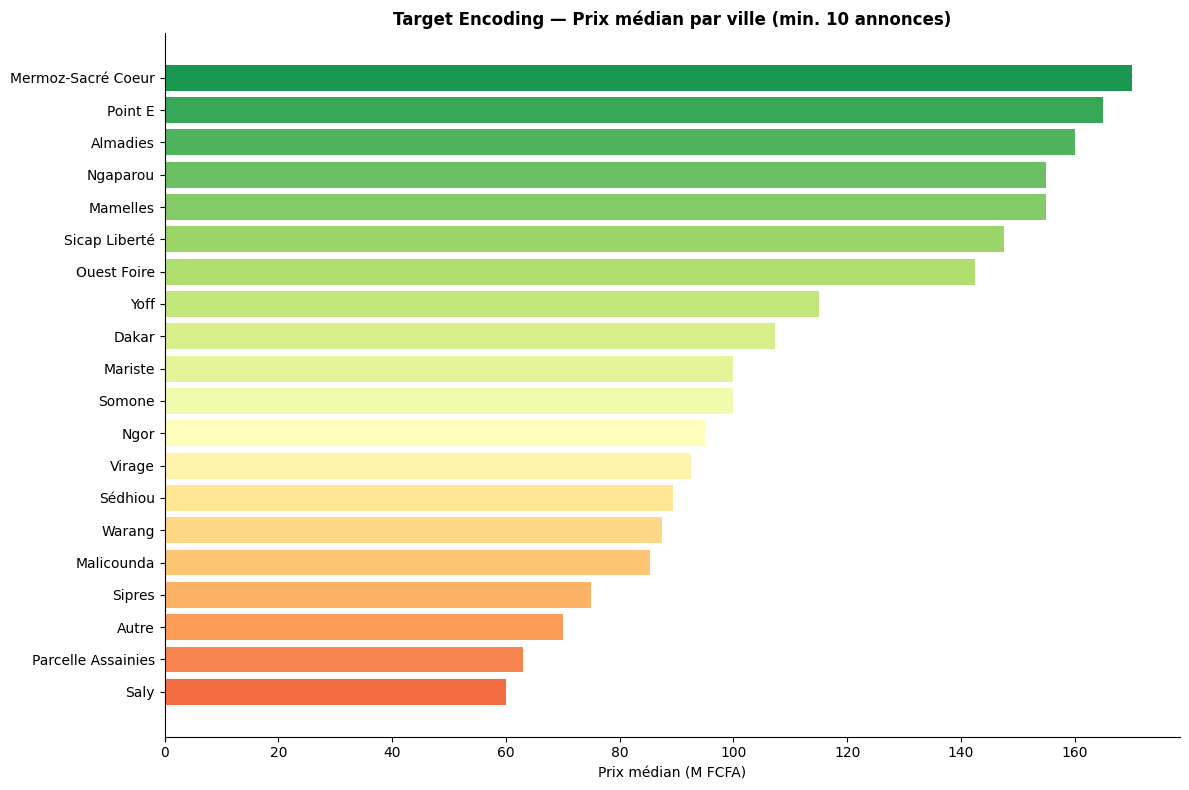

In [54]:
# Target Encoding : encode chaque ville par son prix moyen observé
# Bien plus puissant que OneHotEncoding pour les variables à forte cardinalité
# Standard dans les solutions gagnantes Kaggle et recommandé par sklearn depuis v1.0

city_stats = df.groupby("city")["price"].agg(
    city_mean_price   = "mean",
    city_median_price = "median",
    city_count        = "count",
    city_std_price    = "std",
).reset_index()

# Ajout d un indicateur de fiabilité de l estimation (nombre d annonces)
city_stats["city_reliability"] = (city_stats["city_count"] >= 10).astype(int)

df = df.merge(city_stats, on="city", how="left")

# Prix au m² médian par ville (indicateur KPI pour Gold Layer)
m2_stats = (df[df["prix_m2"].notna() & (df["prix_m2"] < 5e6)]
            .groupby("city")["prix_m2"].median()
            .rename("city_prix_m2_median"))
df = df.join(m2_stats, on="city")

print("TARGET ENCODING CRÉÉ :")
te_cols = ["city_mean_price","city_median_price","city_count","city_std_price","city_prix_m2_median"]
print(df[te_cols].describe().T[["mean","min","max"]].round(0).to_string())

print("CORRÉLATIONS TARGET ENCODING -> PRIX :")
for col in te_cols:
    if col in df.columns:
        r = df[["price",col]].dropna().corr().iloc[0,1]
        print(f"  {col:<25} : {r:.4f}")

# Visualisation Top 20 quartiers par prix médian
top20 = (city_stats[city_stats["city_count"]>=10]
         .sort_values("city_median_price", ascending=True).tail(20))
fig, ax = plt.subplots(figsize=(12,8))
ax.barh(top20["city"], top20["city_median_price"]/1e6,
        color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(top20))))
ax.set_xlabel("Prix médian (M FCFA)")
ax.set_title("Target Encoding — Prix médian par ville (min. 10 annonces)", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/fig_target_encoding.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Diagnostic final

In [55]:
# Liste complète des features
NUMERIC_FEATURES = [
    # Numériques brutes
    "surface_area","bedrooms","bathrooms","garage",
    # Géographiques (8 POI)
    "dist_mer","dist_centre","dist_aeroport","dist_parc",
    "dist_ucad","dist_vdn","dist_port","dist_corniche",
    # Zone et localisation
    "zone_premium","is_premium",
    # Dérivées
    "rooms_total","surface_per_room","bath_bed_ratio",
    "log_surface","log_dist_mer","log_dist_centre",
    # NLP (20 features)
    "has_standing","has_neuf","has_renove","has_piscine","has_meuble",
    "has_climatise","has_ascenseur","has_cuisine_amer","has_parking",
    "has_jardin","has_balcon","has_gardiennage","has_groupe_elec",
    "has_vue_mer","has_vue_degagee","has_concierge","has_digicode",
    "has_titre_foncier","has_viabilise","has_invest",
    "n_premium_feats",
    # Was_missing (indicateurs de manquance)
    "was_missing_surface_area","was_missing_bedrooms","was_missing_bathrooms",
    # Target Encoding
    "city_mean_price","city_median_price","city_count","city_prix_m2_median",
]
CATEGORICAL_FEATURES = ["property_type","source"]
TARGET    = "price"
LOG_TARGET = "log_price"

# Filtrer les features disponibles dans le dataset
NUMERIC_FEATURES     = [f for f in NUMERIC_FEATURES     if f in df.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df.columns]

df["log_price"] = np.log1p(df["price"])

cols_final = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, LOG_TARGET]
df_final   = df[[c for c in cols_final if c in df.columns]].copy()
df_final   = df_final.dropna(subset=[TARGET])

print(f"DATASET FINAL :")
print(f"  Lignes            : {df_final.shape[0]:,}")
print(f"  Colonnes totales  : {df_final.shape[1]}")
print(f"  Features numér.   : {len(NUMERIC_FEATURES)}")
print(f"  Features catég.   : {len(CATEGORICAL_FEATURES)}")
print(f"  Complétude        : {df_final.notna().mean().mean()*100:.1f} %")

missing = df_final[NUMERIC_FEATURES].isnull().sum()
if missing.sum() > 0:
    print("Valeurs manquantes restantes (seront imputées dans pipeline NB3) :")
    print(missing[missing>0].to_string())
else:
    print("Aucune valeur manquante dans les features numériques ✅")

# Matrice de corrélation complète
num_for_corr = ["price","surface_area","bedrooms","bathrooms","dist_mer","dist_centre",
                "zone_premium","is_premium","city_mean_price","n_premium_feats",
                "has_piscine","has_standing","has_vue_mer","has_titre_foncier"]
num_for_corr = [c for c in num_for_corr if c in df_final.columns]
corr_price = (df_final[num_for_corr].corr()["price"]
              .drop("price").sort_values(key=abs, ascending=False))
print("TOP 15 CORRÉLATIONS AVEC LE PRIX :")
for feat, val in list(corr_price.items())[:15]:
    bar  = chr(9608) * int(abs(val)*40)
    sens = "+" if val>0 else "-"
    print(f"  {feat:<28} : {val:>7.4f}  {sens}{bar}")


DATASET FINAL :
  Lignes            : 1,854
  Colonnes totales  : 51
  Features numér.   : 47
  Features catég.   : 2
  Complétude        : 98.0 %
Valeurs manquantes restantes (seront imputées dans pipeline NB3) :
garage    1854
TOP 15 CORRÉLATIONS AVEC LE PRIX :
  city_mean_price              :  0.4737  +██████████████████
  bathrooms                    :  0.3620  +██████████████
  n_premium_feats              :  0.2693  +██████████
  bedrooms                     :  0.2582  +██████████
  surface_area                 :  0.2112  +████████
  has_vue_mer                  :  0.1853  +███████
  has_piscine                  :  0.1713  +██████
  has_standing                 :  0.1549  +██████
  has_titre_foncier            :  0.1434  +█████
  zone_premium                 :  0.1326  +█████
  dist_mer                     : -0.1315  -█████
  is_premium                   :  0.1229  +████
  dist_centre                  : -0.1054  -████


## 12. Sauvegarde

In [56]:
import json

df_final.to_csv("dataset_final.csv", index=False)

config = {
    "NUMERIC_FEATURES":     NUMERIC_FEATURES,
    "CATEGORICAL_FEATURES": CATEGORICAL_FEATURES,
    "TARGET":               TARGET,
    "LOG_TARGET":           LOG_TARGET,
    "n_features_total":     len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES),
    "sources":              df_final.get("source", pd.Series()).unique().tolist()
              if "source" in df_final.columns else [],
}
with open("features_config.json","w") as f:
    json.dump(config, f, indent=2, default=str)

print("✅ dataset_final.csv sauvegardé")
print("✅ features_config.json sauvegardé")
print(f"Récapitulatif des features :")
print(f"  Numériques        : {len(NUMERIC_FEATURES)}")
print(f"  Catégorielles     : {len(CATEGORICAL_FEATURES)}")
print(f"  Total             : {len(NUMERIC_FEATURES)+len(CATEGORICAL_FEATURES)}")
df_final.describe().T


✅ dataset_final.csv sauvegardé
✅ features_config.json sauvegardé
Récapitulatif des features :
  Numériques        : 47
  Catégorielles     : 2
  Total             : 49


,count,mean,std,min,25%,50%,75%,max
surface_area,"1,854.00",204.98,251.24,10.00,61.00,150.00,260.00,"2,860.00"
bedrooms,"1,854.00",4.07,1.74,1.00,3.00,4.00,4.00,20.00
dist_mer,"1,854.00",19.34,28.54,0.10,5.54,6.97,21.61,275.00
dist_centre,"1,854.00",15.41,27.53,0.00,0.00,3.48,17.84,268.99
dist_aeroport,"1,854.00",19.19,28.29,0.83,5.79,7.01,19.86,275.81
dist_parc,"1,854.00",16.12,27.47,1.39,2.17,2.17,16.87,271.00
dist_ucad,"1,854.00",16.39,27.73,0.54,1.82,2.72,19.36,269.84
dist_vdn,"1,854.00",16.67,27.80,0.41,3.35,3.35,17.55,272.33
dist_port,"1,854.00",16.67,26.02,1.76,2.51,5.99,17.36,266.59
dist_corniche,"1,854.00",17.43,28.18,0.93,4.06,4.06,19.97,272.39
